In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from opacus import PrivacyEngine
import gc

transform = transforms.Compose([
    transforms.ToTensor(),  
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader_public = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

train_dataset_2  = datasets.USPS(root='./data', train=True, transform=transform, download=True)
train_loader_private  = DataLoader(dataset=train_dataset_2, batch_size=1000, shuffle=False)
test_dataset  = datasets.USPS(root='./data', train=False, transform=transform, download=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.31MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.55MB/s]
100%|██████████| 6.58M/6.58M [00:07<00:00, 922kB/s] 
100%|██████████| 1.83M/1.83M [00:01<00:00, 1.23MB/s]


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

privacy_engine = PrivacyEngine()


gc.collect()

584

In [11]:
epochs_1 = 5
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(epochs_1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_public:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))  
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

Epoch [1/10]
Training loss 0.5377769048770269
Training accuracy 83.41 %
Testing loss 16.07703751500828
Testing accuracy 46.83607374190334 %
Epoch [2/10]
Training loss 0.1188085233092308
Training accuracy 96.47 %
Testing loss 3.5518243141773036
Testing accuracy 57.14997508719482 %
Epoch [3/10]
Training loss 0.07572550060053666
Training accuracy 97.69333333333333 %
Testing loss 2.2638415725123067
Testing accuracy 57.24962630792227 %
Epoch [4/10]
Training loss 0.058921092613538104
Training accuracy 98.16833333333334 %
Testing loss 1.761467641660332
Testing accuracy 60.98654708520179 %
Epoch [5/10]
Training loss 0.04858428059046467
Training accuracy 98.47333333333333 %
Testing loss 1.452444860701485
Testing accuracy 59.84055804683607 %


In [12]:
epochs_2 = 10
train_losses_2 = []
train_accuracies_2 = []
test_losses_2 = []
test_accuracies_2 = []
model.train()
model, optimizer, train_loader_private = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader_private,
    epochs=10,
    target_epsilon=3,
    target_delta=1e-5,
    max_grad_norm=0.1,
)
for epoch in range(epochs_2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_private:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))
    train_losses_2.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies_2.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses_2.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies_2.append(correct * 100 / total)

    gc.collect()
    model.eval()
    correct = 0
    total = 0
    eval_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            eval_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

print(f"Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")


/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Epoch [1/10]
Training loss 1.5013500265919844
Training accuracy 61.69950738916256 %
Testing loss 5.466799199967225
Testing accuracy 59.49177877428998 %
Epoch [2/10]
Training loss 1.4586756911923944
Training accuracy 61.90345959250649 %
Testing loss 5.315045007319372
Testing accuracy 60.53811659192825 %
Epoch [3/10]
Training loss 1.3111682977766423
Training accuracy 62.59406211520044 %
Testing loss 4.7749522114845435
Testing accuracy 61.983059292476334 %
Epoch [4/10]
Training loss 1.1845756073874942
Training accuracy 65.92224979321753 %
Testing loss 4.281470580961078
Testing accuracy 65.42102640757349 %
Epoch [5/10]
Training loss 1.0061522839874408
Training accuracy 69.89726953230603 %
Testing loss 3.7087765804380104
Testing accuracy 69.00847035376184 %
Epoch [6/10]
Training loss 0.8641962965491018
Training accuracy 73.87533875338754 %
Testing loss 3.177762166682796
Testing accuracy 73.09417040358744 %
Epoch [7/10]
Training loss 0.8163774666046274
Training accuracy 76.42758620689655 %
T

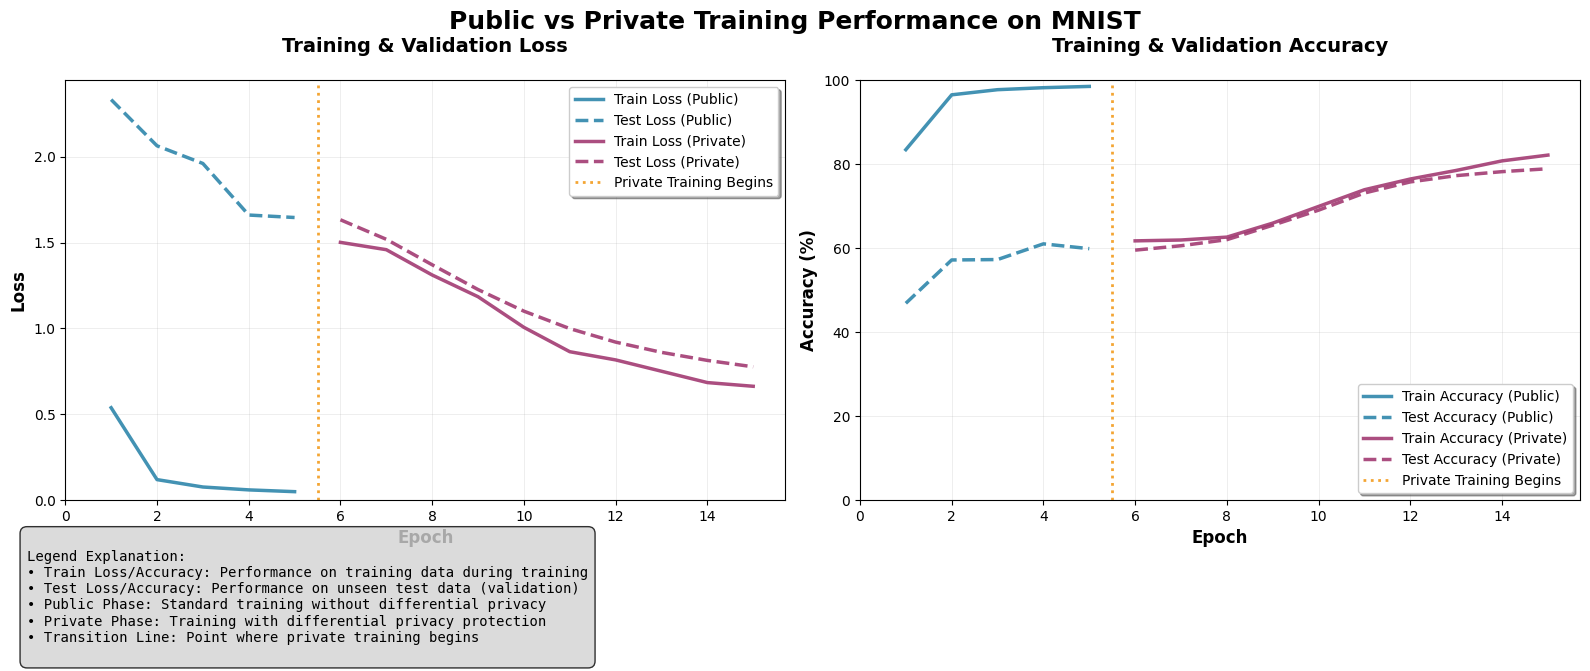

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Combine loss and accuracy for plotting
full_train_losses = train_losses + train_losses_2
full_test_losses = test_losses + test_losses_2
full_train_accuracies = train_accuracies + train_accuracies_2
full_test_accuracies = test_accuracies + test_accuracies_2

# Create epoch ranges
public_epochs = list(range(1, epochs_1 + 1))
private_epochs = list(range(epochs_1 + 1, epochs_1 + epochs_2 + 1))

# Set up the figure with improved styling
plt.rcParams.update({'font.size': 10})  # Set default font size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Define colors for consistency
public_color = '#2E86AB'    # Blue
private_color = '#A23B72'   # Red/Purple
transition_color = '#F18F01' # Orange

# --- Loss Plot ---
ax1.plot(public_epochs, train_losses, color=public_color, linewidth=2.5, 
         label='Train Loss (Public)', alpha=0.9)
ax1.plot(public_epochs, test_losses, color=public_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Public)', alpha=0.9)

ax1.plot(private_epochs, train_losses_2, color=private_color, linewidth=2.5, 
         label='Train Loss (Private)', alpha=0.9)
ax1.plot(private_epochs, test_losses_2, color=private_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Private)', alpha=0.9)

# Add transition line with better styling
ax1.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# --- Accuracy Plot ---
# Note: Your accuracy values are already in percentage (0-100), so don't multiply by 100
ax2.plot(public_epochs, train_accuracies, color=public_color, 
         linewidth=2.5, label='Train Accuracy (Public)', alpha=0.9)
ax2.plot(public_epochs, test_accuracies, color=public_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Public)', alpha=0.9)

ax2.plot(private_epochs, train_accuracies_2, color=private_color, 
         linewidth=2.5, label='Train Accuracy (Private)', alpha=0.9)
ax2.plot(private_epochs, test_accuracies_2, color=private_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Private)', alpha=0.9)

# Add transition line
ax2.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_xlim(left=0)
ax2.set_ylim(0, 100)

# Add overall title with more spacing
fig.suptitle('Public vs Private Training Performance on MNIST', 
             fontsize=18, fontweight='bold', y=0.95)

# Improve layout with space for glossary
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)  # More space for the glossary at bottom

# Add glossary/legend explanation
glossary_text = """
Legend Explanation:
• Train Loss/Accuracy: Performance on training data during training
• Test Loss/Accuracy: Performance on unseen test data (validation)
• Public Phase: Standard training without differential privacy
• Private Phase: Training with differential privacy protection
• Transition Line: Point where private training begins
"""

# Add glossary as text box
props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
fig.text(0.02, 0.02, glossary_text, fontsize=10, verticalalignment='bottom',
         bbox=props, family='monospace')

plt.show()

# Optional: Save the figure in high quality
# plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')

In [18]:
from sliced_wasserstein import sliced_wasserstein_distance

def feature_extractor(loader):
    features = []
    with torch.no_grad():
        for x, _ in loader:
            feature = model(x)
            features.append(feature.numpy())
    return np.concatenate(features, axis=0)

MNIST_features = feature_extractor(train_loader_public)
print("extracted mnist features")

USPS_features = feature_extractor(train_loader_private)
print("extracted USPS features")

print("S.Wasserstein Distance between USPS and MNIST:", sliced_wasserstein_distance(USPS_features, MNIST_features))


ModuleNotFoundError: No module named 'sliced_wasserstein'